In [21]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
import warnings
import os
import sys
import dask.array as da
from Brier import *
import SEDI_v3 as SEDI
import scipy.stats as sstats
import cartopy.crs as ccrs
#from cartopy.feature import NaturalEarthFeature
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker

In [22]:
mods=modict['CanSIPSv3']
modsParF=['CanSIPSv3',]
is_detrend=1
years = [1991, 2020]
il=1
tag='PXGF'

In [23]:
lonW=-170+360
lonE=-110+360
latS=35
latN=65
iP0=20;iP1=-10;jP0=10 # cutoff at beginning of arrays to match parametric area

In [24]:
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))

In [25]:
forigSEDI=xr.open_dataset(SEDI.SEDIpath(mods,is_detrend,years,il))
fParFSEDI=xr.open_dataset(SEDI.SEDIParFpath(modsParF,is_detrend,years,il,tag))

In [26]:
forig

<xarray.Dataset> Size: 2MB
Dimensions:  (X: 360, Y: 181)
Coordinates:
  * X        (X) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * Y        (Y) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
Data variables:
    lon      (X) float32 1kB ...
    lat      (Y) float32 724B ...
    BrS      (Y, X) float64 521kB ...
    BrSref   (Y, X) float64 521kB ...
    BSS      (Y, X) float64 521kB ...

In [27]:
basepath='/space/hall5/sitestore/eccc/crd/ccrn/users/reo000/work/MHW'
f_ice=basepath+f'/OISST/oisst-avhrr-v02r01.regridded1x1.monthly.{years[0]}_{years[-1]}.nc'
#with xr.open_dataset(f_ice) as fice:
fice=xr.open_dataset(f_ice)
icemask1=np.nanmax(fice.ice.data,axis=0)>0
Athresh=.50
Tthresh=.9
#Amax=np.zeros((20,)+np.shape(icemask1))
# for ind in range(0,20):
#     Amax[ind,...]=np.nanmax(fice.ice.data[12*ind:12*(ind+1),...],axis=0)
lost=np.where(fice.ice>Athresh,1,0).sum(axis=0)
#AmaxH=np.mean(np.where(Amax>0,1,0),axis=0)
imask=lost>(1-Tthresh)*np.shape(fice.ice)[0]

In [28]:
pextentNEP=[-152, -123, 43, 60.5]
projNEP=ccrs.Orthographic(central_longitude=-142, central_latitude=50, globe=None)
projG=ccrs.Robinson(central_longitude=-150)

In [29]:
def repl(fig,ax,iproj): # replace axes with ones in same position but with projection
    pos=ax.get_position()
    ax.remove()
    ax=fig.add_axes(rect=pos,projection=iproj)
    return ax

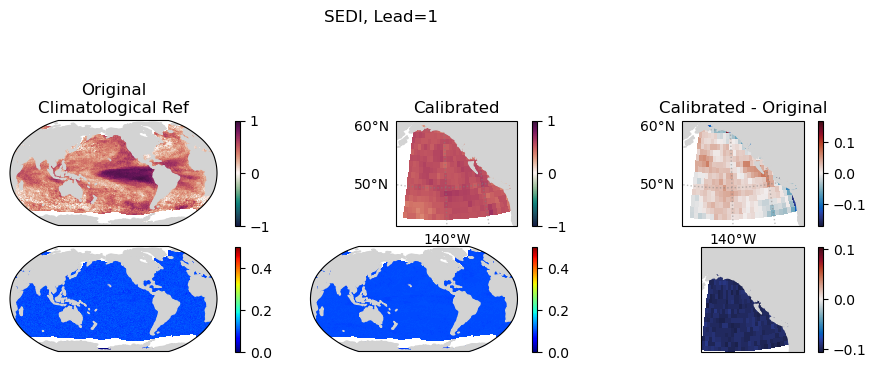

In [40]:
fig,ax=plt.subplots(2,3,figsize=(12,3),gridspec_kw={'width_ratios':[1,.8,.8],'wspace':0})
ax=ax.flatten()
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forigSEDI.SEDI),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projNEP)
m[1]=ax[1].pcolormesh(fParFPers.lon,fParFPers.lat,fParFSEDI.SEDI,vmin=-1,vmax=1,cmap=cmocean.cm.curl,
                transform=ccrs.PlateCarree())
ax[1].set_extent(pextentNEP, ccrs.PlateCarree())
ax[1].set_title('Calibrated')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParFSEDI.SEDI-forigSEDI.SEDI.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original')

for iax in (ax[1],ax[2],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False

ax[3]=repl(fig,ax[3],projG)
m[3]=ax[3].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forigSEDI.TP+forigSEDI.FN)/(40*30*12),vmin=0,vmax=.5,
                 transform=ccrs.PlateCarree(),cmap=plt.get_cmap('jet'))
ax[4]=repl(fig,ax[4],projG)
m[4]=ax[4].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forigSEDI.TP+forigSEDI.FP)/(40*30*12),vmin=0,vmax=.5,
                 transform=ccrs.PlateCarree(),cmap=plt.get_cmap('jet'))
ax[5]=repl(fig,ax[5],projNEP)
m[5]=ax[5].pcolormesh(fParFPers.lon,fParFPers.lat,(fParFSEDI.TP+fParFSEDI.FN-(forigSEDI.TP+forigSEDI.FN).sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1])/(40*30*12),norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
fig.suptitle(f'SEDI, Lead={il}',y=1.25)
for ii in range(0,6):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')

In [8]:
forig.close()
fPers.close()
fParF.close()
fParFPers.close()

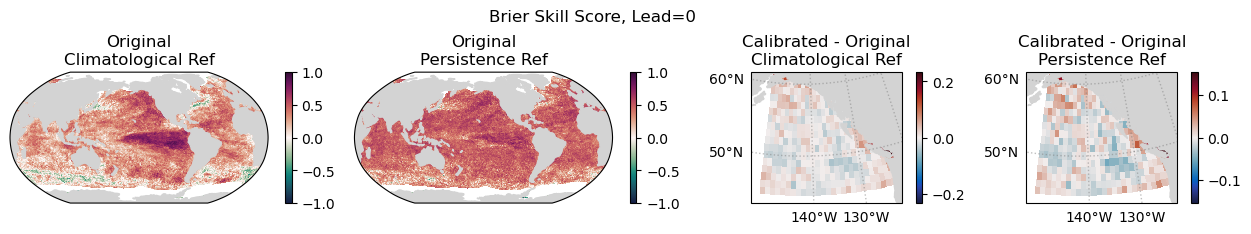

In [10]:
il=0
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))
fig,ax=plt.subplots(1,4,figsize=(16,1.7),gridspec_kw={'width_ratios':[1,1,.8,.8],'wspace':0})
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forig.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projG)
m[1]=ax[1].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,fPers.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[1].set_title('Original\nPersistence Ref')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParF.BSS-forig.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original\nClimatological Ref')
ax[3]=repl(fig,ax[3],projNEP)
m[3]=ax[3].pcolormesh(fParFPers.lon,fParFPers.lat,fParFPers.BSS-fPers.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[3].set_extent(pextentNEP, ccrs.PlateCarree())
ax[3].set_title('Calibrated - Original\nPersistence Ref')
for ii in range(0,4):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')
for iax in (ax[2],ax[3],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f'Brier Skill Score, Lead={il}',y=1.25)
forig.close()
fPers.close()
fParF.close()
fParFPers.close()

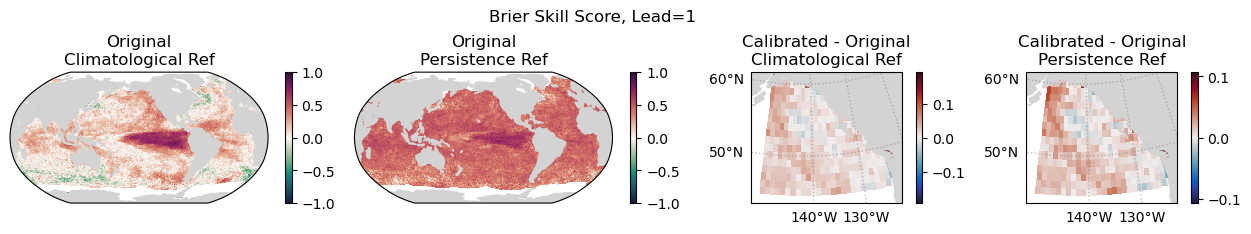

In [11]:
il=1
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))
fig,ax=plt.subplots(1,4,figsize=(16,1.7),gridspec_kw={'width_ratios':[1,1,.8,.8],'wspace':0})
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forig.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projG)
m[1]=ax[1].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,fPers.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[1].set_title('Original\nPersistence Ref')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParF.BSS-forig.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original\nClimatological Ref')
ax[3]=repl(fig,ax[3],projNEP)
m[3]=ax[3].pcolormesh(fParFPers.lon,fParFPers.lat,fParFPers.BSS-fPers.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[3].set_extent(pextentNEP, ccrs.PlateCarree())
ax[3].set_title('Calibrated - Original\nPersistence Ref')
for ii in range(0,4):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')
for iax in (ax[2],ax[3],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f'Brier Skill Score, Lead={il}',y=1.25)
forig.close()
fPers.close()
fParF.close()
fParFPers.close()

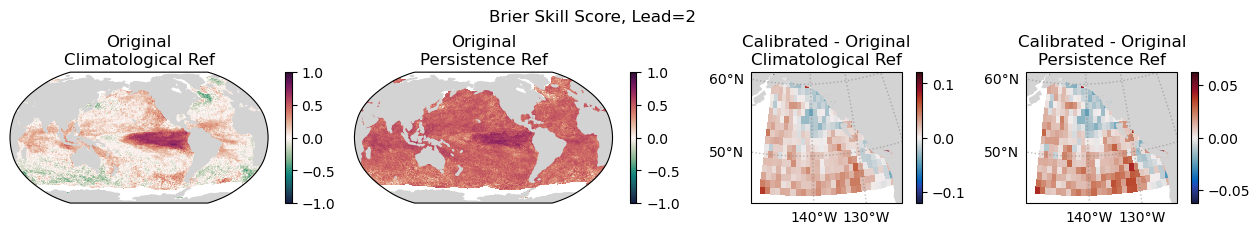

In [12]:
il=2
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))
fig,ax=plt.subplots(1,4,figsize=(16,1.7),gridspec_kw={'width_ratios':[1,1,.8,.8],'wspace':0})
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forig.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projG)
m[1]=ax[1].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,fPers.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[1].set_title('Original\nPersistence Ref')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParF.BSS-forig.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original\nClimatological Ref')
ax[3]=repl(fig,ax[3],projNEP)
m[3]=ax[3].pcolormesh(fParFPers.lon,fParFPers.lat,fParFPers.BSS-fPers.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[3].set_extent(pextentNEP, ccrs.PlateCarree())
ax[3].set_title('Calibrated - Original\nPersistence Ref')
for ii in range(0,4):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')
for iax in (ax[2],ax[3],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f'Brier Skill Score, Lead={il}',y=1.25)
forig.close()
fPers.close()
fParF.close()
fParFPers.close()

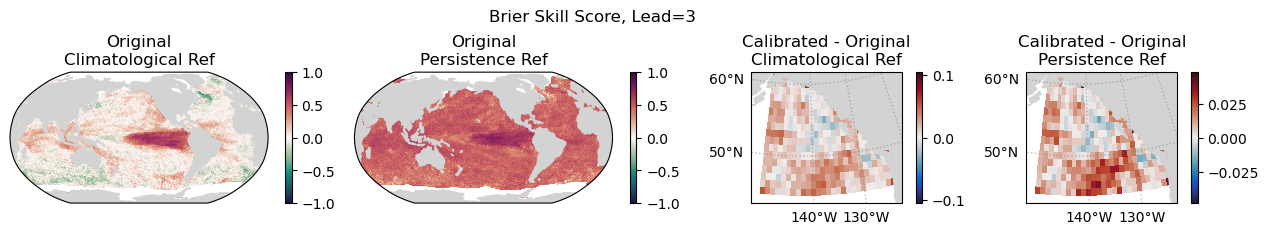

In [13]:
il=3
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))
fig,ax=plt.subplots(1,4,figsize=(16,1.7),gridspec_kw={'width_ratios':[1,1,.8,.8],'wspace':0})
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forig.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projG)
m[1]=ax[1].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,fPers.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[1].set_title('Original\nPersistence Ref')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParF.BSS-forig.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original\nClimatological Ref')
ax[3]=repl(fig,ax[3],projNEP)
m[3]=ax[3].pcolormesh(fParFPers.lon,fParFPers.lat,fParFPers.BSS-fPers.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[3].set_extent(pextentNEP, ccrs.PlateCarree())
ax[3].set_title('Calibrated - Original\nPersistence Ref')
for ii in range(0,4):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')
for iax in (ax[2],ax[3],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f'Brier Skill Score, Lead={il}',y=1.25)
forig.close()
fPers.close()
fParF.close()
fParFPers.close()

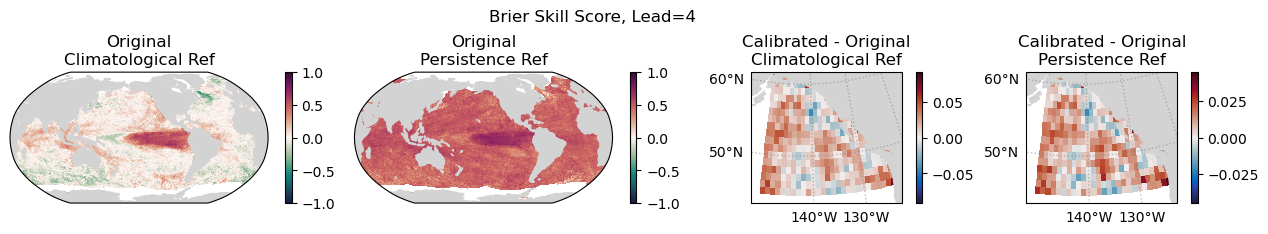

In [14]:
il=4
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))
fig,ax=plt.subplots(1,4,figsize=(16,1.7),gridspec_kw={'width_ratios':[1,1,.8,.8],'wspace':0})
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forig.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projG)
m[1]=ax[1].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,fPers.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[1].set_title('Original\nPersistence Ref')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParF.BSS-forig.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original\nClimatological Ref')
ax[3]=repl(fig,ax[3],projNEP)
m[3]=ax[3].pcolormesh(fParFPers.lon,fParFPers.lat,fParFPers.BSS-fPers.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[3].set_extent(pextentNEP, ccrs.PlateCarree())
ax[3].set_title('Calibrated - Original\nPersistence Ref')
for ii in range(0,4):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')
for iax in (ax[2],ax[3],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f'Brier Skill Score, Lead={il}',y=1.25)
forig.close()
fPers.close()
fParF.close()
fParFPers.close()

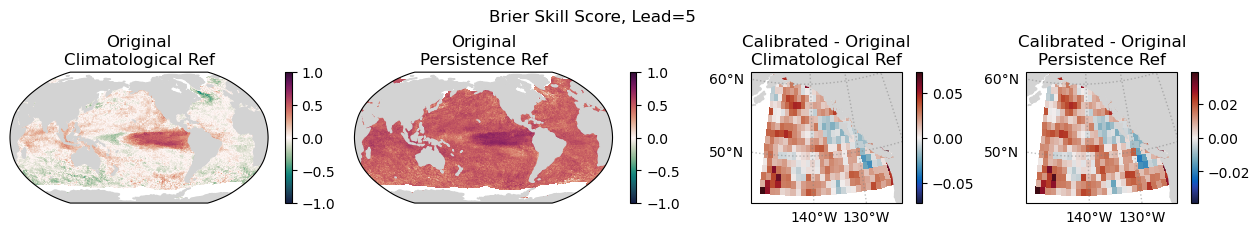

In [15]:
il=5
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))
fig,ax=plt.subplots(1,4,figsize=(16,1.7),gridspec_kw={'width_ratios':[1,1,.8,.8],'wspace':0})
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forig.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projG)
m[1]=ax[1].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,fPers.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[1].set_title('Original\nPersistence Ref')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParF.BSS-forig.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original\nClimatological Ref')
ax[3]=repl(fig,ax[3],projNEP)
m[3]=ax[3].pcolormesh(fParFPers.lon,fParFPers.lat,fParFPers.BSS-fPers.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[3].set_extent(pextentNEP, ccrs.PlateCarree())
ax[3].set_title('Calibrated - Original\nPersistence Ref')
for ii in range(0,4):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')
for iax in (ax[2],ax[3],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f'Brier Skill Score, Lead={il}',y=1.25)
forig.close()
fPers.close()
fParF.close()
fParFPers.close()

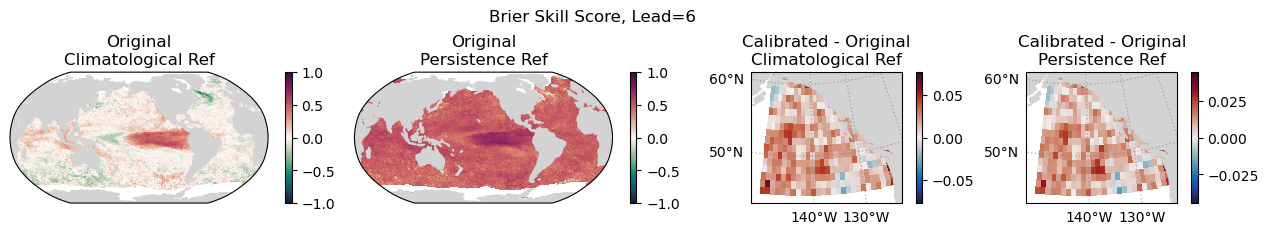

In [16]:
il=6
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))
fig,ax=plt.subplots(1,4,figsize=(16,1.7),gridspec_kw={'width_ratios':[1,1,.8,.8],'wspace':0})
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forig.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projG)
m[1]=ax[1].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,fPers.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[1].set_title('Original\nPersistence Ref')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParF.BSS-forig.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original\nClimatological Ref')
ax[3]=repl(fig,ax[3],projNEP)
m[3]=ax[3].pcolormesh(fParFPers.lon,fParFPers.lat,fParFPers.BSS-fPers.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[3].set_extent(pextentNEP, ccrs.PlateCarree())
ax[3].set_title('Calibrated - Original\nPersistence Ref')
for ii in range(0,4):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')
for iax in (ax[2],ax[3],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f'Brier Skill Score, Lead={il}',y=1.25)
forig.close()
fPers.close()
fParF.close()
fParFPers.close()

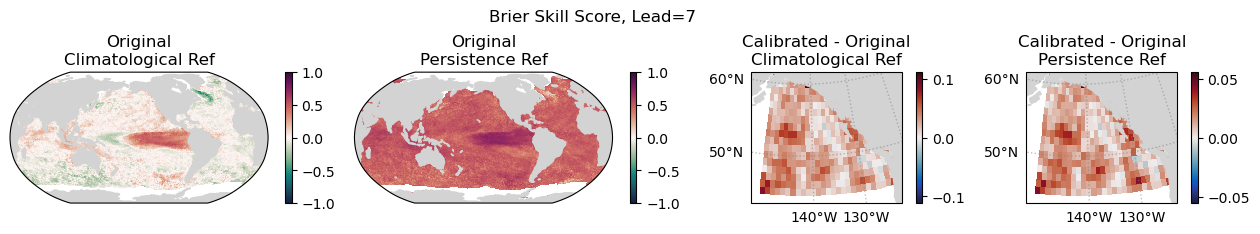

In [17]:
il=7
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))
fig,ax=plt.subplots(1,4,figsize=(16,1.7),gridspec_kw={'width_ratios':[1,1,.8,.8],'wspace':0})
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forig.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projG)
m[1]=ax[1].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,fPers.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[1].set_title('Original\nPersistence Ref')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParF.BSS-forig.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original\nClimatological Ref')
ax[3]=repl(fig,ax[3],projNEP)
m[3]=ax[3].pcolormesh(fParFPers.lon,fParFPers.lat,fParFPers.BSS-fPers.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[3].set_extent(pextentNEP, ccrs.PlateCarree())
ax[3].set_title('Calibrated - Original\nPersistence Ref')
for ii in range(0,4):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')
for iax in (ax[2],ax[3],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f'Brier Skill Score, Lead={il}',y=1.25)
forig.close()
fPers.close()
fParF.close()
fParFPers.close()

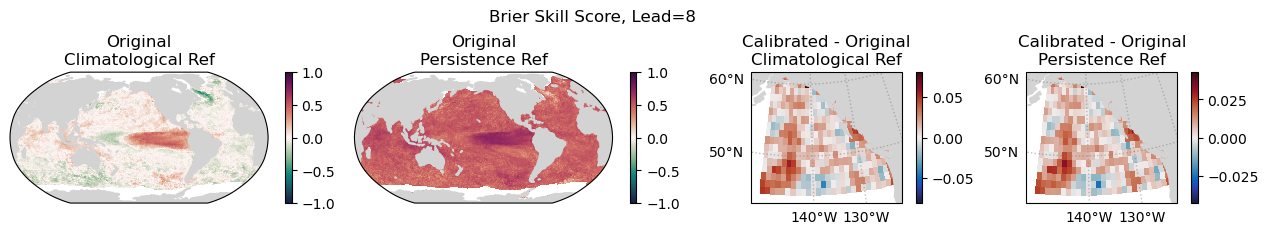

In [18]:
il=8
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))
fig,ax=plt.subplots(1,4,figsize=(16,1.7),gridspec_kw={'width_ratios':[1,1,.8,.8],'wspace':0})
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forig.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projG)
m[1]=ax[1].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,fPers.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[1].set_title('Original\nPersistence Ref')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParF.BSS-forig.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original\nClimatological Ref')
ax[3]=repl(fig,ax[3],projNEP)
m[3]=ax[3].pcolormesh(fParFPers.lon,fParFPers.lat,fParFPers.BSS-fPers.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[3].set_extent(pextentNEP, ccrs.PlateCarree())
ax[3].set_title('Calibrated - Original\nPersistence Ref')
for ii in range(0,4):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')
for iax in (ax[2],ax[3],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f'Brier Skill Score, Lead={il}',y=1.25)
forig.close()
fPers.close()
fParF.close()
fParFPers.close()

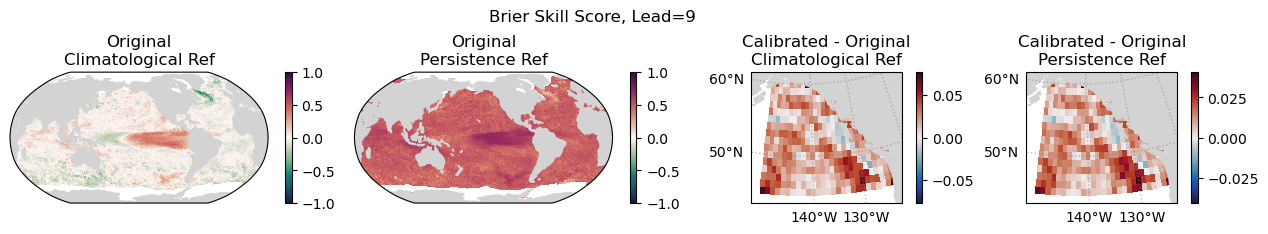

In [19]:
il=9
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))
fig,ax=plt.subplots(1,4,figsize=(16,1.7),gridspec_kw={'width_ratios':[1,1,.8,.8],'wspace':0})
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forig.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projG)
m[1]=ax[1].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,fPers.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[1].set_title('Original\nPersistence Ref')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParF.BSS-forig.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original\nClimatological Ref')
ax[3]=repl(fig,ax[3],projNEP)
m[3]=ax[3].pcolormesh(fParFPers.lon,fParFPers.lat,fParFPers.BSS-fPers.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[3].set_extent(pextentNEP, ccrs.PlateCarree())
ax[3].set_title('Calibrated - Original\nPersistence Ref')
for ii in range(0,4):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')
for iax in (ax[2],ax[3],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f'Brier Skill Score, Lead={il}',y=1.25)
forig.close()
fPers.close()
fParF.close()
fParFPers.close()

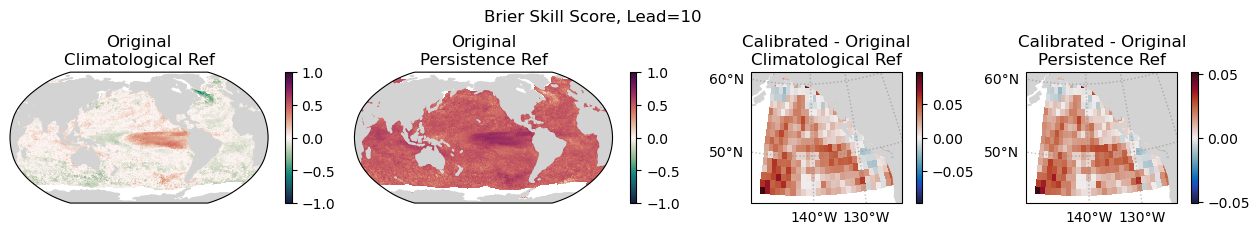

In [20]:
il=10
forig=xr.open_dataset(BSSpath(mods,is_detrend,years,il))
fPers=xr.open_dataset(BSSPersistPath(mods,is_detrend,years,il))
fParF=xr.open_dataset(BSSParFpath(modsParF,is_detrend,years,il,tag))
fParFPers=xr.open_dataset(BSSPersistParFPath(modsParF,is_detrend,years,il,tag))
fig,ax=plt.subplots(1,4,figsize=(16,1.7),gridspec_kw={'width_ratios':[1,1,.8,.8],'wspace':0})
m={}
ax[0]=repl(fig,ax[0],projG)
m[0]=ax[0].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,forig.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[0].set_title('Original\nClimatological Ref')
ax[1]=repl(fig,ax[1],projG)
m[1]=ax[1].pcolormesh(forig.lon,forig.lat,np.ma.masked_where(imask,fPers.BSS),vmin=-1,vmax=1,transform=ccrs.PlateCarree(),cmap=cmocean.cm.curl)
ax[1].set_title('Original\nPersistence Ref')
ax[2]=repl(fig,ax[2],projNEP)
m[2]=ax[2].pcolormesh(fParFPers.lon,fParFPers.lat,fParF.BSS-forig.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[2].set_extent(pextentNEP, ccrs.PlateCarree())
ax[2].set_title('Calibrated - Original\nClimatological Ref')
ax[3]=repl(fig,ax[3],projNEP)
m[3]=ax[3].pcolormesh(fParFPers.lon,fParFPers.lat,fParFPers.BSS-fPers.BSS.sel(X=slice(lonW,lonE),Y=slice(latS,latN)).values[jP0:,iP0:iP1],norm=mpl.colors.CenteredNorm(),
                cmap=cmocean.cm.balance,transform=ccrs.PlateCarree())
ax[3].set_extent(pextentNEP, ccrs.PlateCarree())
ax[3].set_title('Calibrated - Original\nPersistence Ref')
for ii in range(0,4):
    fig.colorbar(m[ii],ax=ax[ii])
    ax[ii].add_feature(cfeature.LAND,zorder=2,color='lightgray')
for iax in (ax[2],ax[3],):
    #iax.add_feature(cfeature.LAND,zorder=1,color='lightgray')
    gl = iax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle=':',)
    gl.xlocator = mticker.FixedLocator([-140, -130, -120,])
    gl.ylocator = mticker.FixedLocator([40, 50, 60,70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f'Brier Skill Score, Lead={il}',y=1.25)
forig.close()
fPers.close()
fParF.close()
fParFPers.close()